In [9]:
import geopandas as gpd
import contextily as cx
import pyproj

In [10]:
lin_subw = r'C:\AmbientalPro\CursoCompleto\MOD08\dados\SIRGAS_SHP_linhametro_line.shp'
est_subw = r'C:\AmbientalPro\CursoCompleto\MOD08\dados\SIRGAS_SHP_estacaometro_point.shp'

In [13]:
df_lin_subw = gpd.read_file(lin_subw)
est_lin_subw = gpd.read_file(est_subw)

In [14]:
df_lin_subw.head()

In [5]:
est_lin_subw.head()

,emt_linha,emt_empres,emt_situac,emt_nome,geometry
0,VERMELHA,METRO,OPERANDO,CORINTHIANS-ITAQUERA,POINT (349839.380 7395675.047)
1,VERMELHA,METRO,OPERANDO,ARTUR ALVIM,POINT (348457.592 7395884.165)
2,VERMELHA,METRO,OPERANDO,PATRIARCA,POINT (346732.712 7396874.617)
3,VERMELHA,METRO,OPERANDO,GUILHERMINA-ESPERANÇA,POINT (345181.965 7397070.921)
4,VERMELHA,METRO,OPERANDO,VILA MATILDE,POINT (343708.935 7396765.736)


In [6]:
print(df_lin_subw.crs)
print(est_lin_subw.crs)

epsg:31983
None


In [7]:
type(est_lin_subw)

geopandas.geodataframe.GeoDataFrame

In [8]:
# gdf = gpd.GeoDataFrame(est_lin_subw,  geometry = 'geometry')

In [15]:
gdf2 = est_lin_subw.set_crs(df_lin_subw.crs)

In [16]:
gdf2.crs

<Derived Projected CRS: EPSG:31983>
Name: SIRGAS 2000 / UTM zone 23S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Brazil - between 48°W and 42°W, northern and southern hemispheres, onshore and offshore.
- bounds: (-48.0, -33.5, -42.0, 5.13)
Coordinate Operation:
- name: UTM zone 23S
- method: Transverse Mercator
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

<AxesSubplot:>

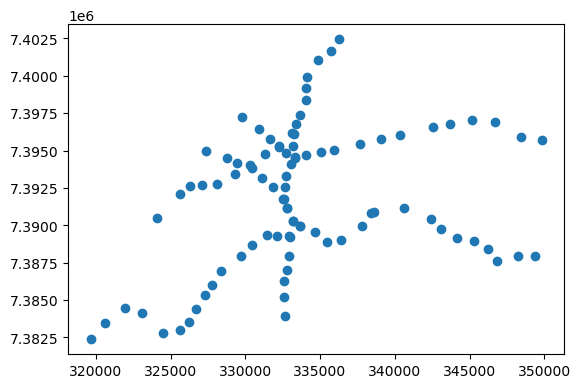

In [17]:
gdf2.plot() 

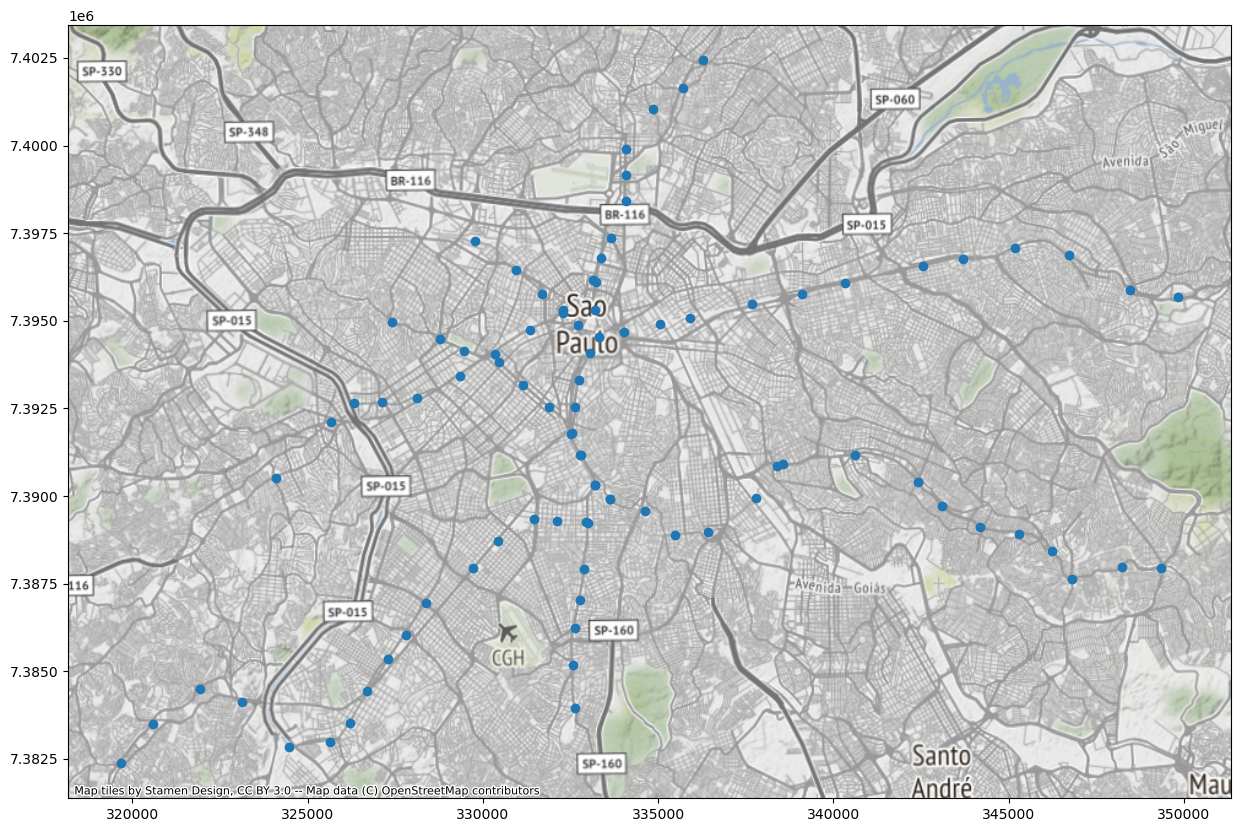

In [18]:
ax = gdf2.plot(figsize=(15, 15), color="None")
gdf2.plot(ax=ax)
cx.add_basemap(ax, crs=gdf2.crs)

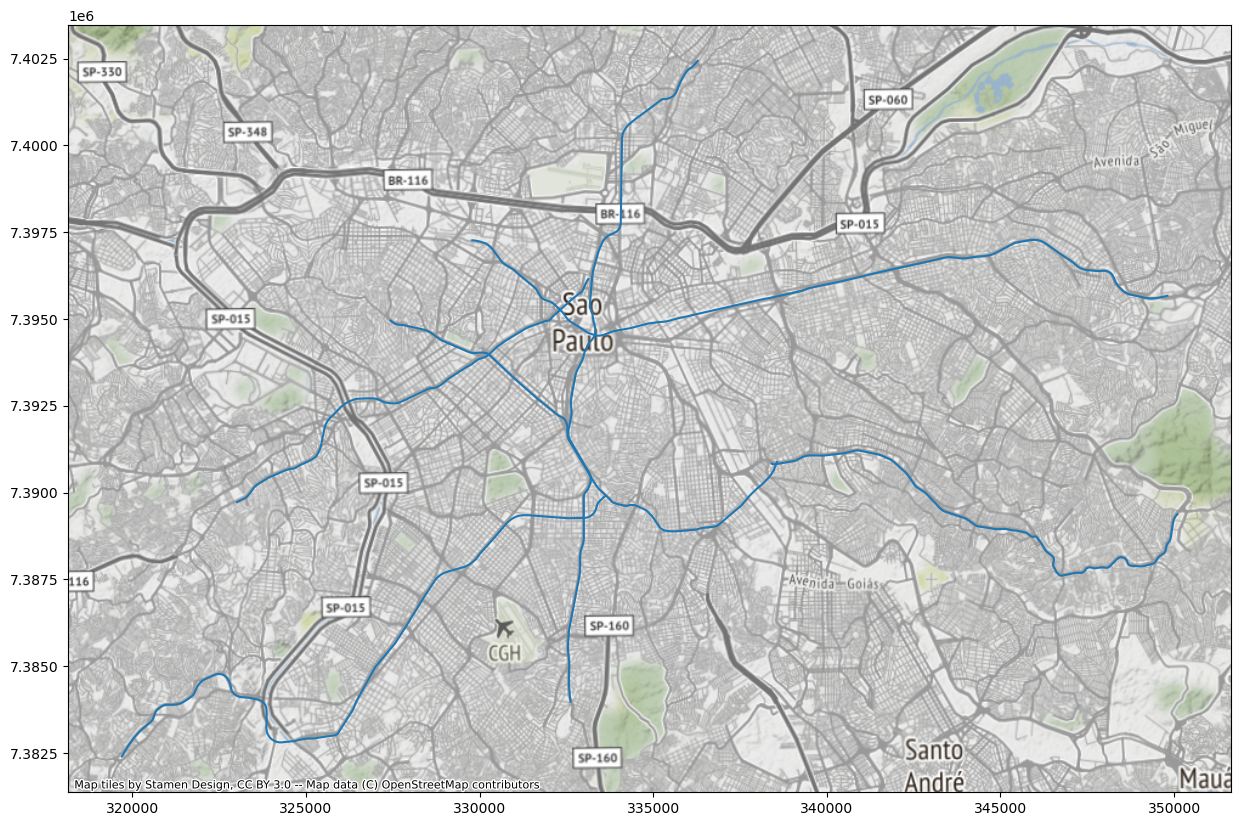

In [13]:
ax = df_lin_subw.plot(figsize=(15, 15), color="None")
df_lin_subw.plot(ax=ax)
cx.add_basemap(ax, crs=df_lin_subw.crs)

In [19]:
lin_sub_buf = df_lin_subw.buffer(500)
est_sub_buf = gdf2.buffer(1000)

In [20]:
est_sub = gpd.GeoDataFrame({'geometry': lin_sub_buf})
lin_sub = gpd.GeoDataFrame({'geometry': est_sub_buf})

In [21]:
est_lin_sub_union = est_sub.union(lin_sub)

C:\Users\limei\Anaconda3\envs\geodev\lib\site-packages\geopandas\base.py:31: UserWarning: The indices of the two GeoSeries are different.
  warn("The indices of the two GeoSeries are different.")


In [22]:
est_lin_sub_union = gpd.GeoDataFrame({'geometry': est_lin_sub_union})

In [23]:
est_lin_sub_dissolv = est_lin_sub_union.dissolve()

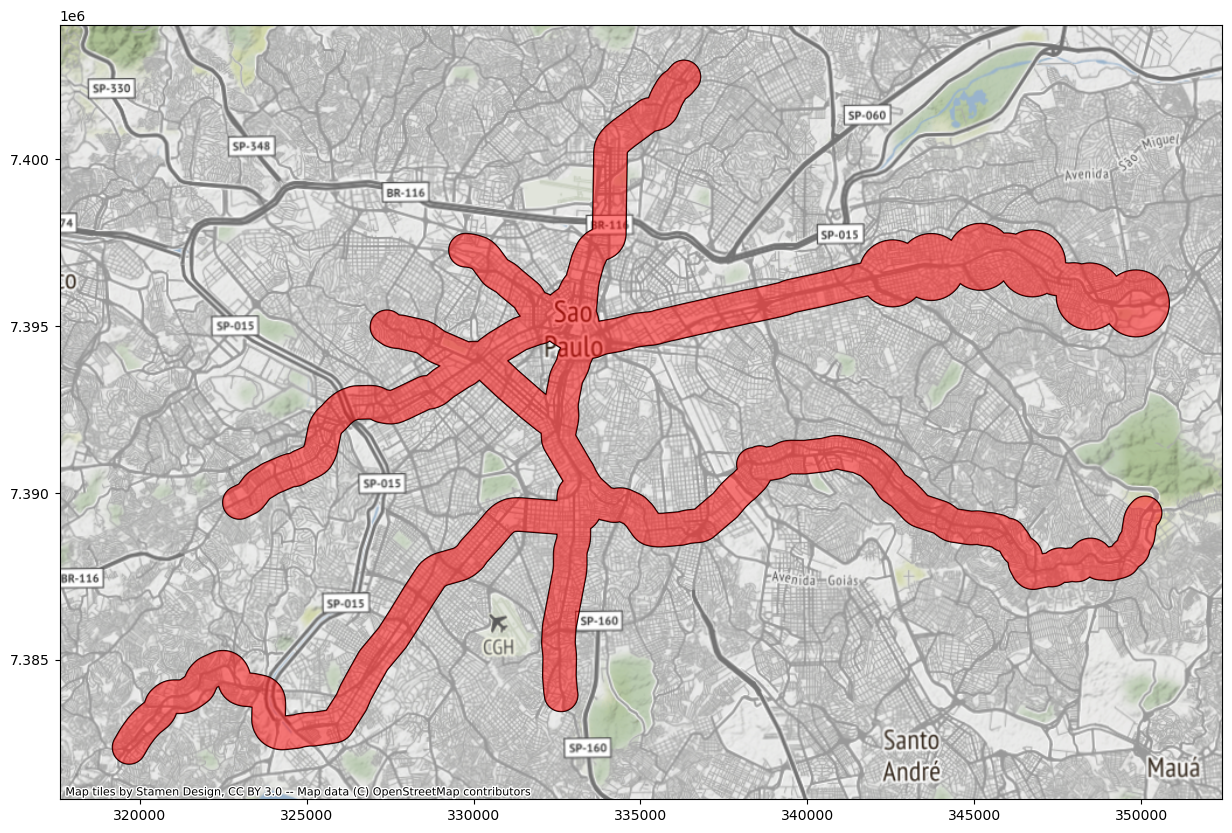

In [24]:
ax = est_lin_sub_dissolv.plot(figsize=(15, 15), edgecolor='black',color="none")

est_lin_sub_dissolv.plot(ax=ax, edgecolor='none', color='red', alpha=0.5)

cx.add_basemap(ax, crs=est_lin_sub_dissolv.crs)

In [26]:
est_lin_sub_dissolv.to_file(r"C:\AmbientalPro\CursoCompleto\MOD08\dados\countries.shp")